In [27]:
import sys
sys.path.append("/home/anncollin/Desktop/Nucleoles/SingleCellEmb")

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from SSL.model import create_vit_small_backbone, DINOHead, DINOStudent

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


#######################################################################################################
# CONFIG
#######################################################################################################
cfg = {}

cfg["patch_size"] = 8
cfg["in_channels"] = "both"
cfg["out_dim"] = 256
cfg["architecture"] = "small"

cfg["data_root"] = "/home/anncollin/Desktop/Nucleoles/dataset/MyDB/"
cfg["label_path"] = "/home/anncollin/Desktop/Nucleoles/dataset/labels/unique_drugs.csv"
cfg["callibration_path"] = "/home/anncollin/Desktop/Nucleoles/dataset/labels/callibration.csv"

checkpoint_path = "/home/anncollin/Desktop/Nucleoles/SingleCellEmb/Results/DAPI+EGFP-small8-256_LR-05_callibration/checkpoints/final_weights.pth"

device = "cuda" if torch.cuda.is_available() else "cpu"


#######################################################################################################
# LOAD MODEL
#######################################################################################################
def load_trained_student(checkpoint_path, cfg, device="cuda"):

    in_chans_map = {"egfp":1,"dapi":1,"both":2}

    backbone = create_vit_small_backbone(
        architecture=cfg["architecture"],
        patch_size=cfg["patch_size"],
        in_chans=in_chans_map[cfg["in_channels"]]
    )

    head = DINOHead(
        in_dim=backbone.num_features,
        out_dim=cfg["out_dim"]
    )

    student = DINOStudent(backbone, head).to(device)

    ckpt = torch.load(checkpoint_path, map_location=device)

    if "student_state_dict" in ckpt:
        student.load_state_dict(ckpt["student_state_dict"])
    else:
        student.load_state_dict(ckpt)

    student.eval()

    return student


#######################################################################################################
# GET DMSO / SCR WELLS
#######################################################################################################
def get_dmso_scr_paths(data_root, label_csv):

    df = pd.read_csv(label_csv, header=None, dtype=str)
    df.columns = ["plate","well_code","drug"]

    df["drug"] = df["drug"].str.strip()
    df = df[df["drug"].isin(["DMSO","SCR"])]

    paths = []

    for _,row in df.iterrows():

        p = os.path.join(data_root,row["plate"],f"{row['well_code']}.npy")

        if os.path.isfile(p):
            paths.append(p)

    return paths


student = load_trained_student(checkpoint_path,cfg,device=device)

paths = get_dmso_scr_paths(cfg["data_root"],cfg["callibration_path"])

print("Number of wells:",len(paths))

#######################################################################################################
# NORMALIZATION
#######################################################################################################
def _normalize_to_uint8(img):
    return np.clip(img.astype(np.float32) * 1200, 0, 255).astype(np.uint8)


#######################################################################################################
# NORMALIZATION
#######################################################################################################
def _normalize_to_uint8(img):
    return np.clip(img.astype(np.float32) * 1200, 0, 255).astype(np.uint8)


#######################################################################################################
# DISPLAY SAMPLE CELLS (DMSO / SCR) WITH MODIFICATIONS
#######################################################################################################
def show_example_cells(paths, cfg, n_rows=5, n_cols=15):

    channel_map = {"egfp":[0], "dapi":[1], "both":[0,1]}
    chans = channel_map[cfg["in_channels"]]

    df = pd.read_csv(cfg["callibration_path"], header=None, dtype=str)
    df.columns = ["plate","well_code","drug"]

    target = n_rows * n_cols

    dmso_cells = []
    scr_cells  = []

    for npy_path in paths:

        plate = os.path.basename(os.path.dirname(npy_path))
        well  = os.path.basename(npy_path).replace(".npy","")

        drug = df[(df["plate"]==plate) & (df["well_code"]==well)]["drug"].values[0].strip()

        data = np.load(npy_path, mmap_mode="r")

        idx = np.random.choice(data.shape[0], size=min(50, data.shape[0]), replace=False)

        for i in idx:

            img = data[i][chans]
            img = torch.from_numpy(np.asarray(img)).float().unsqueeze(0)

            img = modify_batch(img)

            img = img.squeeze(0).cpu().numpy()

            if drug == "DMSO" and len(dmso_cells) < target:
                dmso_cells.append(img)

            if drug == "SCR" and len(scr_cells) < target:
                scr_cells.append(img)

        if len(dmso_cells) >= target and len(scr_cells) >= target:
            break


    fig, ax = plt.subplots(2*n_rows, n_cols, figsize=(1.6*n_cols, 1.6*2*n_rows))


    ###################################################################################################
    # DMSO
    ###################################################################################################
    for i in range(target):

        r = i // n_cols
        c = i % n_cols

        if i < len(dmso_cells):

            img = dmso_cells[i]

            if img.shape[0] == 2:
                egfp = _normalize_to_uint8(img[0])
                dapi = _normalize_to_uint8(img[1])
                rgb  = np.stack([np.zeros_like(egfp), egfp, dapi], axis=-1)
                ax[r,c].imshow(rgb)
            else:
                ax[r,c].imshow(_normalize_to_uint8(img[0]), cmap="gray")

        ax[r,c].axis("off")


    ###################################################################################################
    # SCR
    ###################################################################################################
    for i in range(target):

        r = n_rows + i // n_cols
        c = i % n_cols

        if i < len(scr_cells):

            img = scr_cells[i]

            if img.shape[0] == 2:
                egfp = _normalize_to_uint8(img[0])
                dapi = _normalize_to_uint8(img[1])
                rgb  = np.stack([np.zeros_like(egfp), egfp, dapi], axis=-1)
                ax[r,c].imshow(rgb)
            else:
                ax[r,c].imshow(_normalize_to_uint8(img[0]), cmap="gray")

        ax[r,c].axis("off")


    ###################################################################################################
    # TITLES
    ###################################################################################################
    ax[0,0].set_title("DMSO", fontsize=16, loc="left")
    ax[n_rows,0].set_title("SCR", fontsize=16, loc="left")
    plt.show()


Number of wells: 2


In [30]:
def modify_batch(x):

    # set DAPI channel to zero
    if x.shape[1] == 2:
        x[:, 1, :, :] = 0

    return x

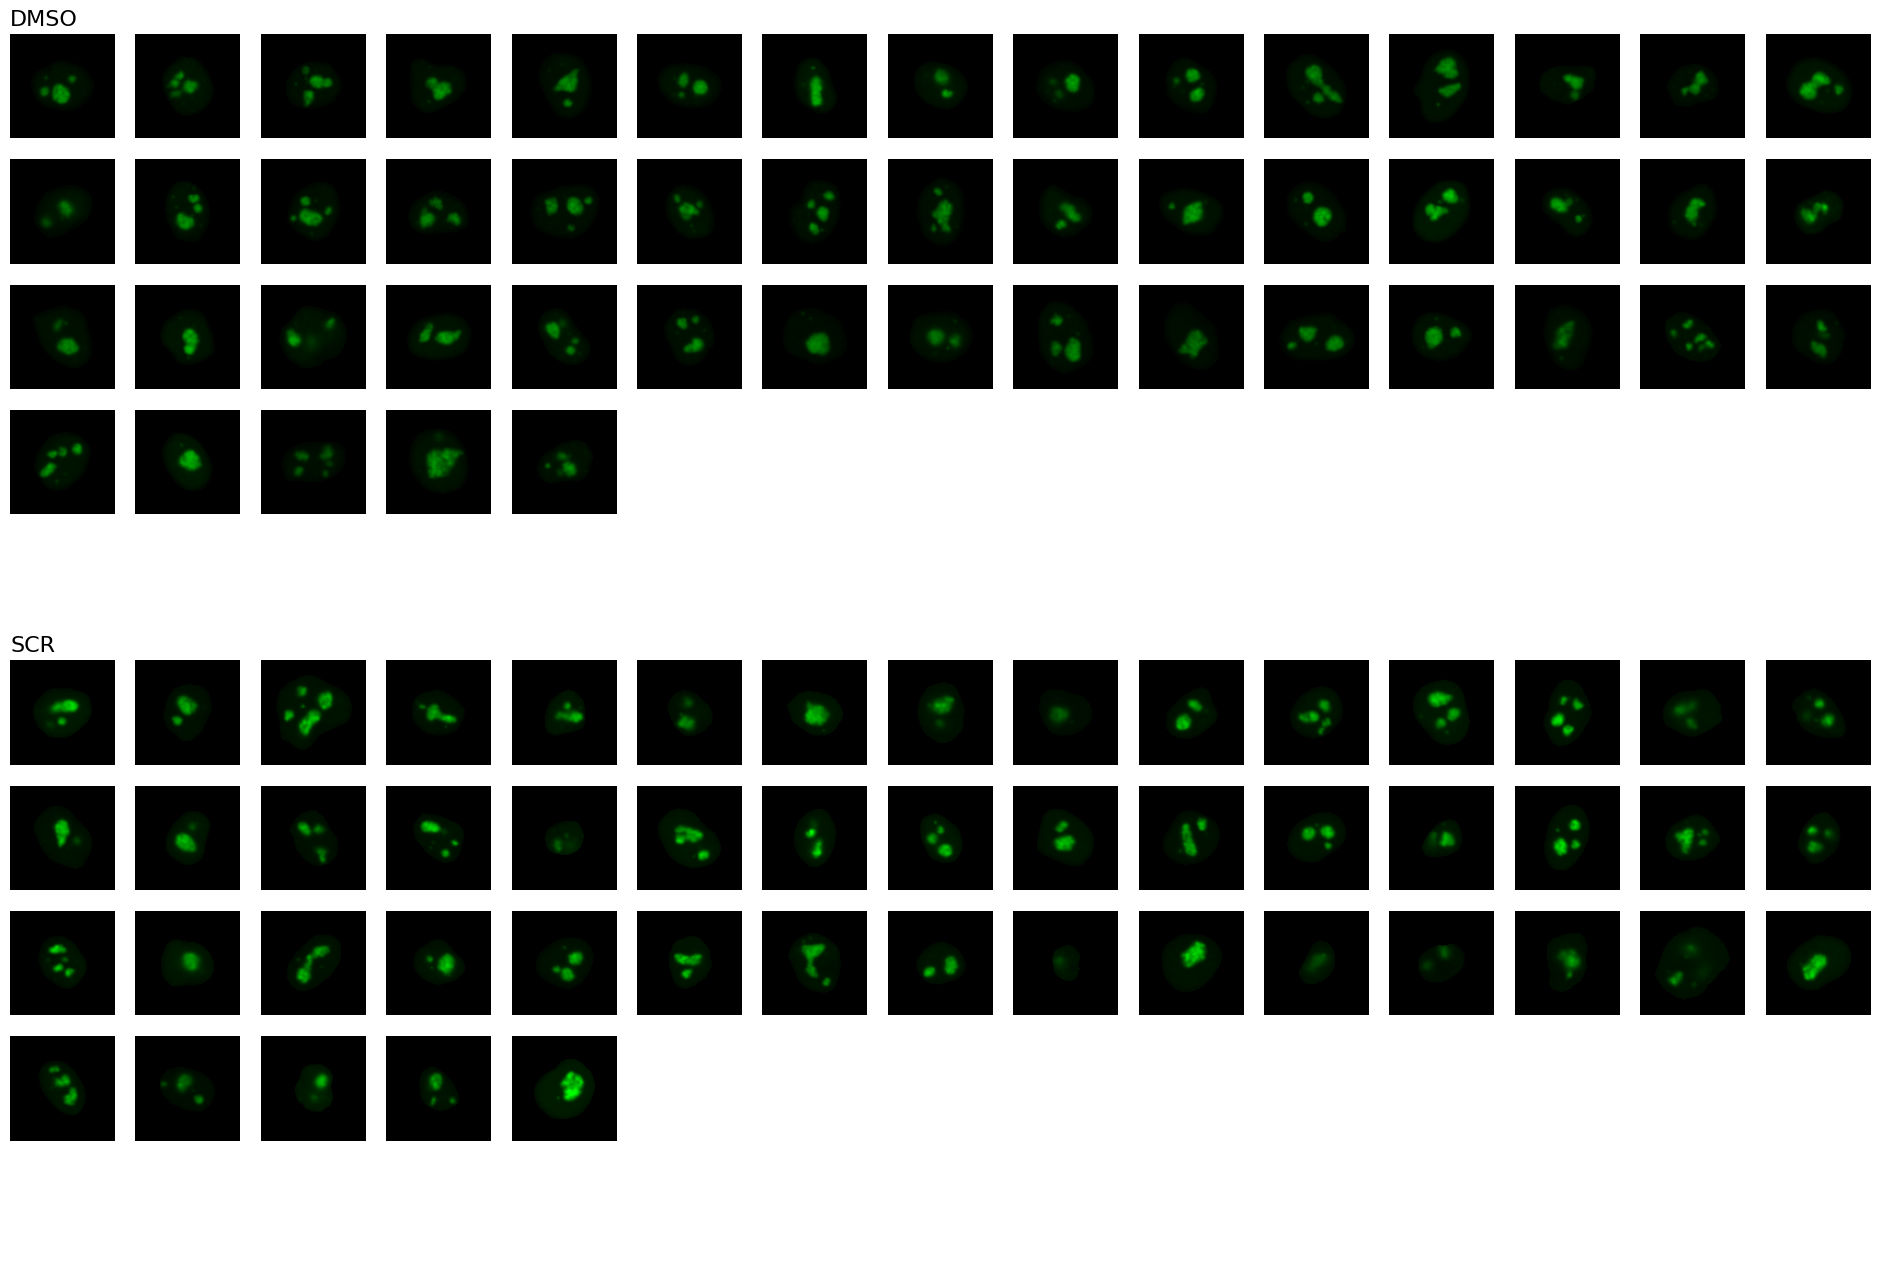

In [31]:
show_example_cells(paths, cfg)

In [32]:
#######################################################################################################
# COMPUTE EMBEDDINGS
#######################################################################################################
@torch.no_grad()
def compute_embeddings(student,paths,cfg,device="cuda",batch_size=256):

    channel_map = {"egfp":[0],"dapi":[1],"both":[0,1]}
    chans = channel_map[cfg["in_channels"]]

    embeddings = []
    labels_cells = []

    df = pd.read_csv(cfg["callibration_path"],header=None,dtype=str)
    df.columns = ["plate","well_code","drug"]

    for npy_path in paths:

        plate = os.path.basename(os.path.dirname(npy_path))
        well  = os.path.basename(npy_path).replace(".npy","")

        drug = df[(df["plate"]==plate)&(df["well_code"]==well)]["drug"].values[0].strip()

        data = np.load(npy_path,mmap_mode="r")

        arr = data[:,chans]

        N = arr.shape[0]

        for i in range(0,N,batch_size):

            batch = arr[i:i+batch_size]

            batch = torch.from_numpy(np.asarray(batch)).float()

            batch = modify_batch(batch)

            batch = batch.to(device)

            z = student.backbone(batch)

            embeddings.append(z.cpu())

        labels_cells.extend([drug]*N)

    embeddings = torch.cat(embeddings,dim=0)
    labels_cells = np.array(labels_cells)

    return embeddings,labels_cells


embeddings,labels_cells = compute_embeddings(student,paths,cfg,device)

print("Total cells:",embeddings.shape[0])

Total cells: 3525


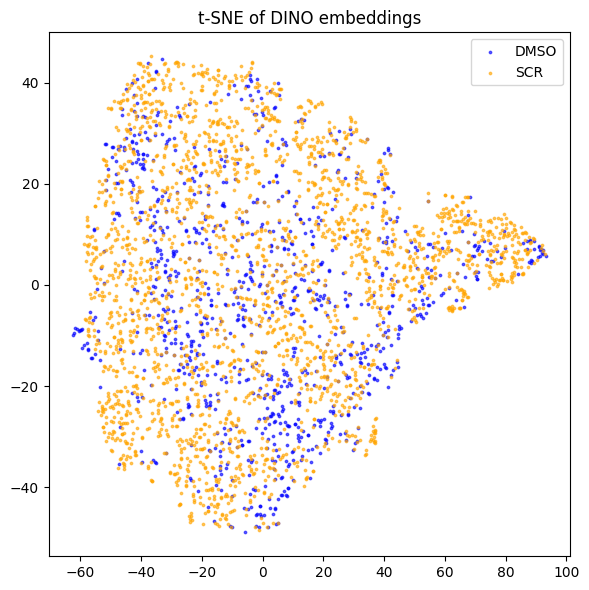

Cosine similarity: 0.9985476732254028
Cosine distance: 0.001452326774597168


In [33]:
from sklearn.manifold import TSNE


#######################################################################################################
# TSNE
#######################################################################################################
X = embeddings.numpy()

tsne = TSNE(n_components=2,perplexity=30,init="pca",random_state=0)

X2 = tsne.fit_transform(X)

mask_dmso = labels_cells=="DMSO"
mask_scr  = labels_cells=="SCR"

plt.figure(figsize=(6,6))

plt.scatter(X2[mask_dmso,0],X2[mask_dmso,1],s=3,c="blue",label="DMSO",alpha=0.6)
plt.scatter(X2[mask_scr,0],X2[mask_scr,1],s=3,c="orange",label="SCR",alpha=0.6)

plt.legend()
plt.title("t-SNE of DINO embeddings")

plt.tight_layout()
plt.show()


#######################################################################################################
# COSINE DISTANCE BETWEEN CLASS MEANS
#######################################################################################################
emb_dmso = embeddings[mask_dmso]
emb_scr  = embeddings[mask_scr]

mean_dmso = emb_dmso.mean(dim=0)
mean_scr  = emb_scr.mean(dim=0)

cos_sim = torch.nn.functional.cosine_similarity(
    mean_dmso.unsqueeze(0),
    mean_scr.unsqueeze(0)
).item()

cos_dist = 1 - cos_sim

print("Cosine similarity:",cos_sim)
print("Cosine distance:",cos_dist)

In [ ]:
import torch
from SSL.utils import compute_expert_annotation_metric


@torch.no_grad()
def evaluate_expertAnnotation_modified(cfg, checkpoint_path):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    in_channels = cfg.get("in_channels", "both")

    # use the existing function already defined in the notebook
    student = load_trained_student(checkpoint_path, cfg, device=device)

    ###################################################################################################
    # WRAP BACKBONE
    ###################################################################################################
    original_backbone = student.backbone

    class ModifiedBackbone(torch.nn.Module):

        def __init__(self, backbone):
            super().__init__()
            self.backbone = backbone

        def forward(self, x):
            x = modify_batch(x)
            return self.backbone(x)

    student.backbone = ModifiedBackbone(original_backbone)

    annotations_path = "/home/anncollin/Desktop/Nucleoles/SingleCellEmb/SSL/annotations.csv"

    score = compute_expert_annotation_metric(
        student=student,
        data_root=cfg["data_root"],
        annotations_csv=annotations_path,
        in_channels=in_channels,
        device=device,
    )

    print("-" * 60)
    print(f"Expert annotation satisfaction (PROTOTYPE, DAPI=0): {score:.2f}%")
    print("-" * 60)

    return score


evaluate_expertAnnotation_modified(cfg, checkpoint_path)